In [3]:

import torch
import torchvision
import matplotlib.pyplot as plt
import torch.nn as nn

In [4]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,)),
    ]
)
data = torchvision.datasets.MNIST(
    root="data", train=True, download=True, transform=transform
)
data[0][0].shape

torch.Size([1, 28, 28])

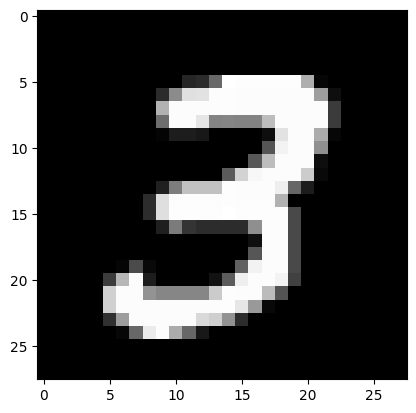

In [5]:
image, label = data[7]
plt.imshow(image.squeeze(), cmap="gray")

In [6]:
train_loader = torch.utils.data.DataLoader(data, batch_size=64, shuffle=True)

train_loader

for i, j in train_loader:
    print(i.shape)
    print(j.shape)
    break

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [7]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)
    
    def forward(self, x):
        x = x.view(x.size(0), 784) 
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        return self.fc3(x)


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleNet().to('cuda')
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)
device

'cuda'

In [9]:
for epoch in range(10):
    pred = model.train()
    lossno = 0
    for images, labels in train_loader:
        model.zero_grad()
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        
        lossno += loss.item()
        
    print(
        f"Epoch {epoch+1}, Loss: {lossno:.4f}"
    )
        
        
        

Epoch 1, Loss: 261.0830
Epoch 2, Loss: 179.2895
Epoch 3, Loss: 159.1010
Epoch 4, Loss: 149.7247
Epoch 5, Loss: 134.3915
Epoch 6, Loss: 136.0701
Epoch 7, Loss: 128.4870
Epoch 8, Loss: 127.1387
Epoch 9, Loss: 113.1300
Epoch 10, Loss: 120.1903


In [10]:
test_dataset = torchvision.datasets.MNIST(
    root="data", train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=True)

In [16]:
model.eval()
wrong = []
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        mismatch = predicted != labels

        for img, true_label, pred_label in zip(
            images[mismatch], labels[mismatch], predicted[mismatch]
        ):
            wrong.append((img.cpu(), true_label.item(), pred_label.item()))

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")
print("Number of wrong predictions:", len(wrong))

Accuracy: 95.45%
Number of wrong predictions: 455


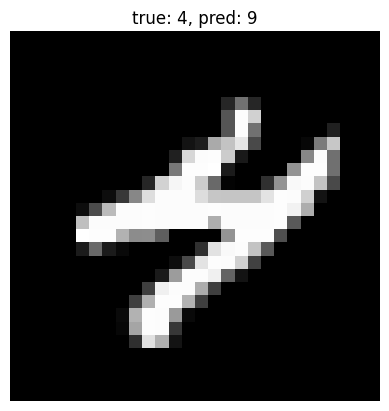

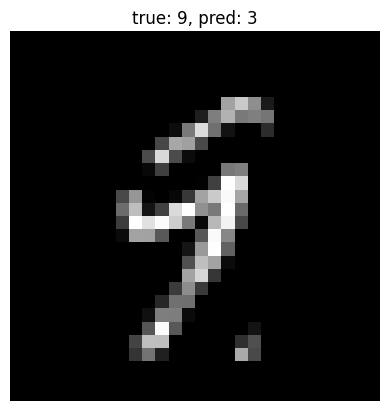

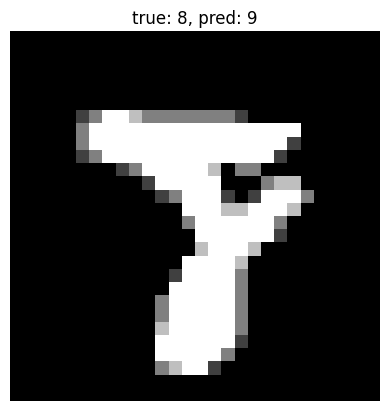

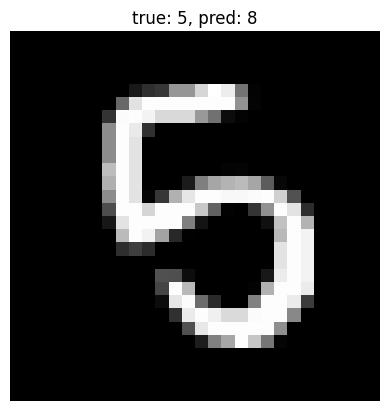

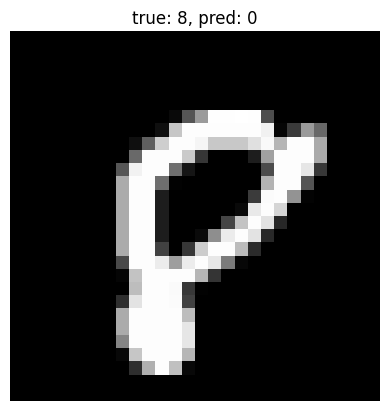

In [19]:
for i, (img, true_label, pred_label) in enumerate(wrong[:5]):
    plt.figure()
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"true: {true_label}, pred: {pred_label}")
    plt.axis("off")
    plt.show()